In [142]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform, norm

SEED = 42
np.random.seed(SEED)

# Algoritmo de *rejection sampling*
- Sea $\tilde{p}(x) = e^{-(x-2)^2} + 0.5e^{-(x+1)^2}$ y $q = \text{Uniforme}(x)$.
- Responder a las siguientes preguntas:

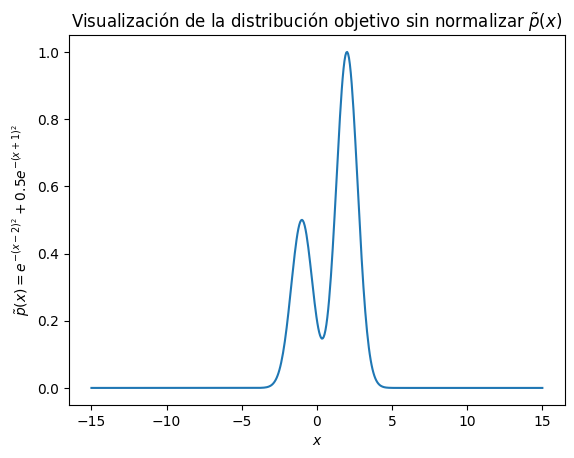

In [143]:
def p_tilde(x):
    return np.exp(-(x - 2)**2) + 0.5 * np.exp(-(x + 1)**2)

x = np.linspace(-15, 15, 500)
y_p_tilde = p_tilde(x)

plt.plot(x, y_p_tilde)
plt.xlabel(r"$x$")
plt.ylabel(r"$\tilde{p}(x) = e^{-(x-2)^2} + 0.5e^{-(x+1)^2}$")
plt.title(r"Visualización de la distribución objetivo sin normalizar $\tilde{p}(x)$")
plt.show()

1. ¿Cuál debería ser el soporte de $q$?
- Como se puede observar en la representación de $\tilde{p}(x)$, lo más adecuado es que el soporte de $q$ sea $[-5, 5]$.

In [144]:
def q(x):
    return uniform.pdf(x, loc=-5, scale=10)

2. ¿Cúal debería ser el valor mínimo de $C$?

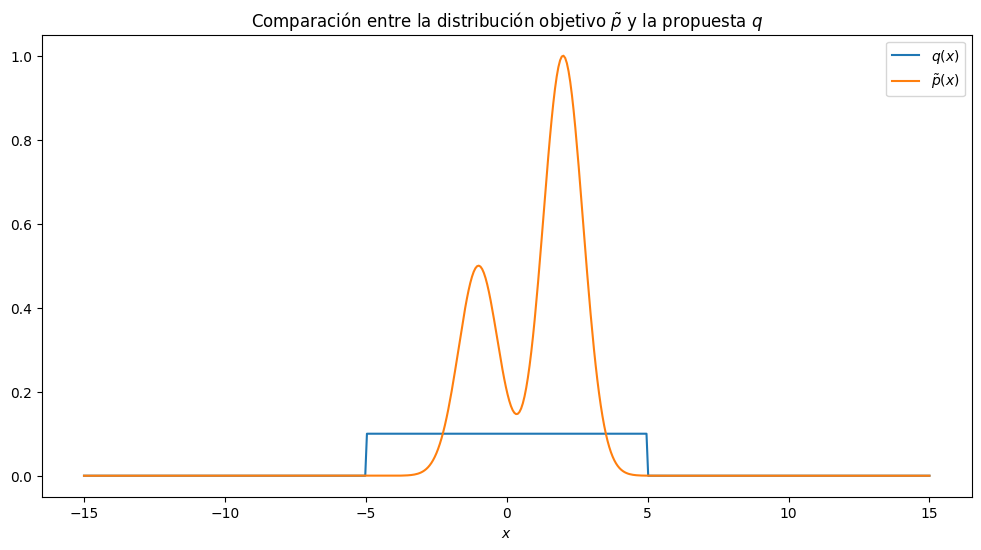

In [145]:
y_q = q(x)

plt.figure(figsize=(12, 6))
plt.plot(x, y_q, label=r"$q(x)$")
plt.plot(x, y_p_tilde, label=r"$\tilde{p}(x)$")
plt.xlabel(r"$x$")
plt.title(r"Comparación entre la distribución objetivo $\tilde{p}$ y la propuesta $q$")
plt.legend()
plt.show()

- Teniendo en cuenta que el soporte de nuestra distribución propuesta es $[-5, 5]$ y que, por tanto, $q(x) = 0.1, \forall x \in [-5, 5]$, tendríamos que multiplicar el output por 10 como mínimo. Entonces, asignamos $C = 10$.

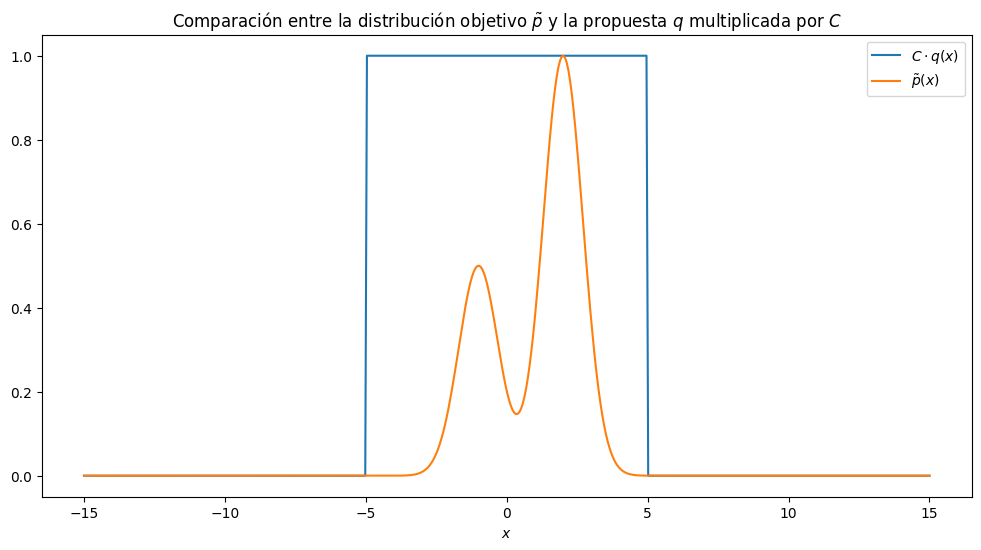

In [146]:
C = 10
y_C_q = C * q(x)

plt.figure(figsize=(12, 6))
plt.plot(x, y_C_q, label=r"$C \cdot q(x)$")
plt.plot(x, y_p_tilde, label=r"$\tilde{p}(x)$")
plt.xlabel(r"$x$")
plt.title(r"Comparación entre la distribución objetivo $\tilde{p}$ y la propuesta $q$ multiplicada por $C$")
plt.legend()
plt.show()

3. Generar $N$ muestras de $p$.

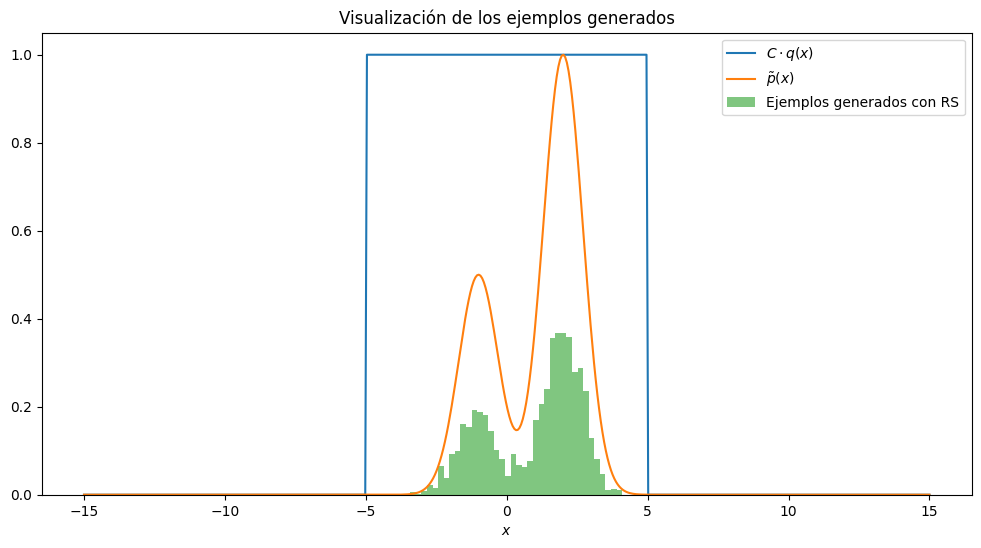

In [147]:
def rejection_sampling(f, Cq_pdf, num_samples):
    samples = []
    while len(samples) < num_samples:
        x_i = np.random.uniform(-5, 5)
        u = np.random.uniform(0, max(Cq_pdf))
        if u < f(x_i):
            samples.append(x_i)
    return np.array(samples)

N = 2000
p_samples = rejection_sampling(p_tilde, y_C_q, N)

plt.figure(figsize=(12, 6))
plt.plot(x, y_C_q, label=r"$C \cdot q(x)$")
plt.plot(x, y_p_tilde, label=r"$\tilde{p}(x)$")
plt.hist(p_samples, bins=40, density=True, alpha=0.6, label="Ejemplos generados con RS")
plt.xlabel(r"$x$")
plt.title(r"Visualización de los ejemplos generados")
plt.legend()
plt.show()

4. Estimar $\mathbb{E}_{x \sim p}[f(x)]$, con $f(x) = (1 + e^{-x})^{-1}$.

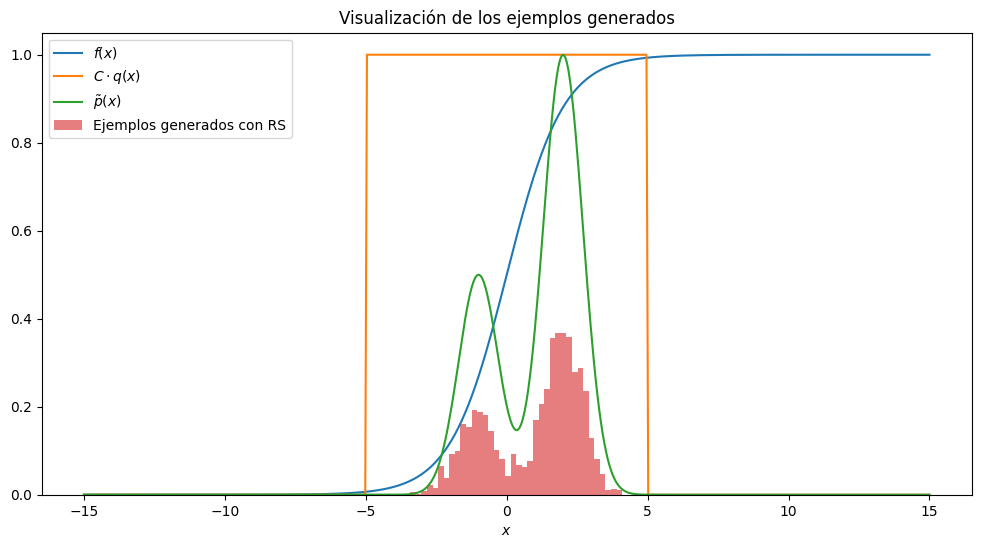

In [148]:
def f(x):
    return (1 + np.exp(-x))**(-1)

y_f = f(x)

plt.figure(figsize=(12, 6))
plt.plot(x, y_f, label=r"$f(x)$")
plt.plot(x, y_C_q, label=r"$C \cdot q(x)$")
plt.plot(x, y_p_tilde, label=r"$\tilde{p}(x)$")
plt.hist(p_samples, bins=40, density=True, alpha=0.6, label="Ejemplos generados con RS")
plt.xlabel(r"$x$")
plt.title(r"Visualización de los ejemplos generados")
plt.legend()
plt.show()

In [149]:
E_f = np.mean(f(p_samples))
print(f"- La estimación del valor esperado de f(x) con x ~ p es: {E_f}")

- La estimación del valor esperado de f(x) con x ~ p es: 0.6647628666267308


5. ¿Cuál es el porcentaje de muestras rechazadas?

In [150]:
def rejected_ratio(f, Cq_pdf, num_samples):
    num_accepted = 0
    num_rejected = 0
    while num_accepted < num_samples:
        x_i = np.random.uniform(-5, 5)
        u = np.random.uniform(0, max(Cq_pdf))
        if u < f(x_i):
            num_accepted += 1
        else:
            num_rejected += 1
    
    return (num_rejected / (num_rejected + num_samples))

ratios = []
for _ in range(20):
    ratio = rejected_ratio(f, y_C_q, N)
    ratios.append(ratio)
ratios = np.array(ratios)
print(f"- De media se rechaza un {(np.mean(ratios) * 100):.1f}% de las muestras generadas.")

- De media se rechaza un 50.1% de las muestras generadas.


6. Repetir utilizando una distribución gaussiana para $q$. En este caso ¿qué media y varianza elegirías para $q$?
- En cuanto a la media $\mu$, deberíamos elegir un valor tal que la moda de la distribución quede en la región de mayor densidad de la distribución objetivo. En nuestro caso, como podemos observar en la ilustración de la distribución $\tilde{p}(x)$, ésto ocurriría cuando el valor de la media de $q(x)$ sea, aproximadamente, $1.5$.
- Para la varianza, deberíamos escoger un valor que haga que se cubra el rango de la distribución, que en nuestro caso sería aproximadamente $\sqrt{5}$ (siendo la desviación típica $\sigma^2 = 5$).

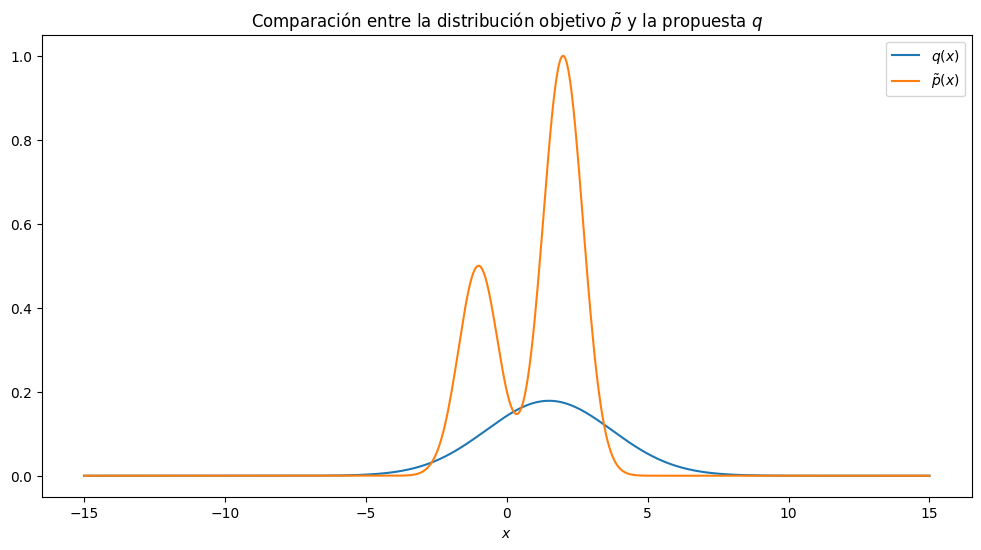

In [151]:
def q(x, loc, scale):
    return norm.pdf(x, loc=loc, scale=scale)

mu_val = 1.5
var_val = np.sqrt(5.0)
y_q = q(x, mu_val, var_val)

plt.figure(figsize=(12, 6))
plt.plot(x, y_q, label=r"$q(x)$")
plt.plot(x, y_p_tilde, label=r"$\tilde{p}(x)$")
plt.xlabel(r"$x$")
plt.title(r"Comparación entre la distribución objetivo $\tilde{p}$ y la propuesta $q$")
plt.legend()
plt.show()

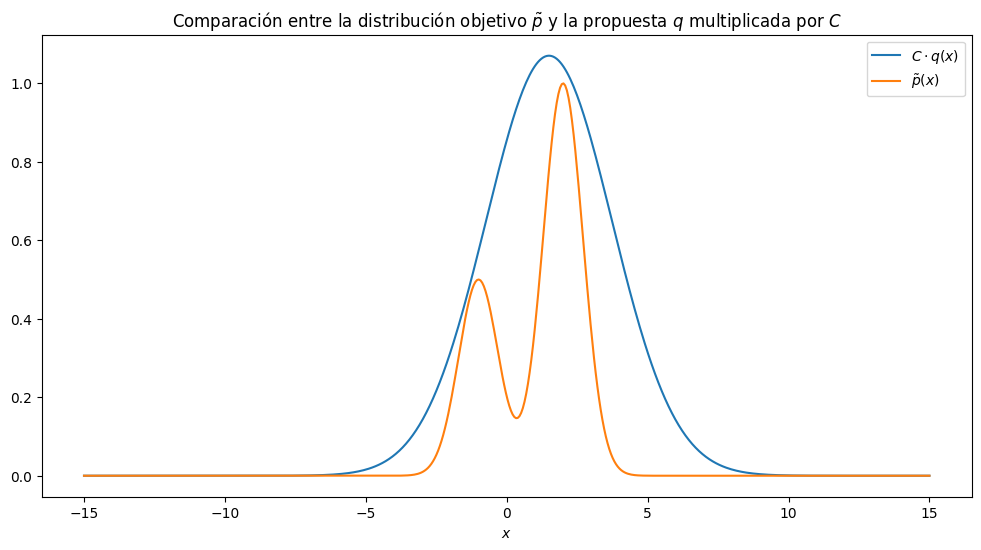

In [152]:
C = 6
y_C_q = C * q(x, mu_val, var_val)

plt.figure(figsize=(12, 6))
plt.plot(x, y_C_q, label=r"$C \cdot q(x)$")
plt.plot(x, y_p_tilde, label=r"$\tilde{p}(x)$")
plt.xlabel(r"$x$")
plt.title(r"Comparación entre la distribución objetivo $\tilde{p}$ y la propuesta $q$ multiplicada por $C$")
plt.legend()
plt.show()

7. Generar $N$ muestras de $p$.

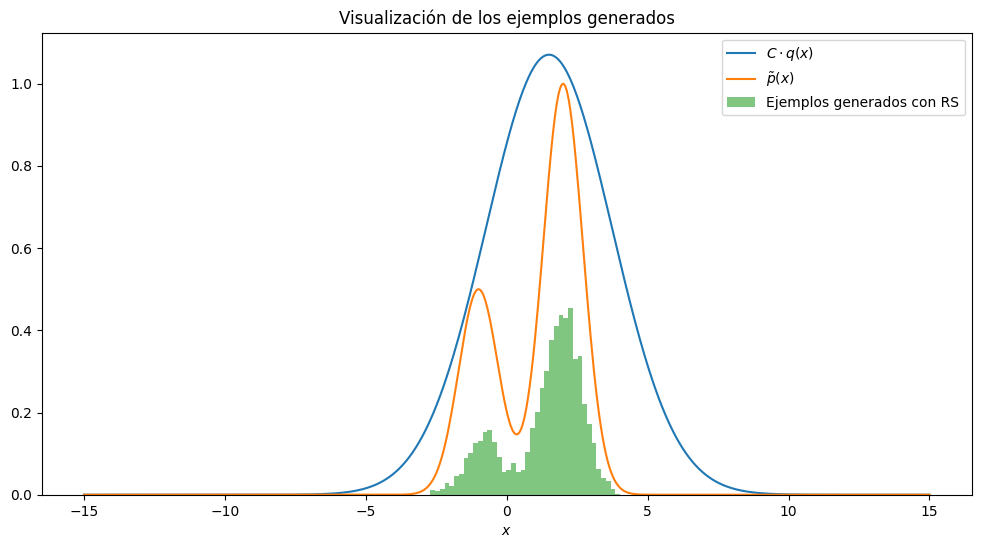

In [153]:
def rejection_sampling(f, Cq_pdf, num_samples):
    samples = []
    while len(samples) < num_samples:
        x_i = np.random.normal(mu_val, var_val)
        u = np.random.uniform(0, max(Cq_pdf))
        if u < f(x_i):
            samples.append(x_i)
    return np.array(samples)

N = 2000
p_samples = rejection_sampling(p_tilde, y_C_q, N)

plt.figure(figsize=(12, 6))
plt.plot(x, y_C_q, label=r"$C \cdot q(x)$")
plt.plot(x, y_p_tilde, label=r"$\tilde{p}(x)$")
plt.hist(p_samples, bins=40, density=True, alpha=0.6, label="Ejemplos generados con RS")
plt.xlabel(r"$x$")
plt.title(r"Visualización de los ejemplos generados")
plt.legend()
plt.show()

8. Estimar $\mathbb{E}_{x \sim p}[f(x)]$ de nuevo.

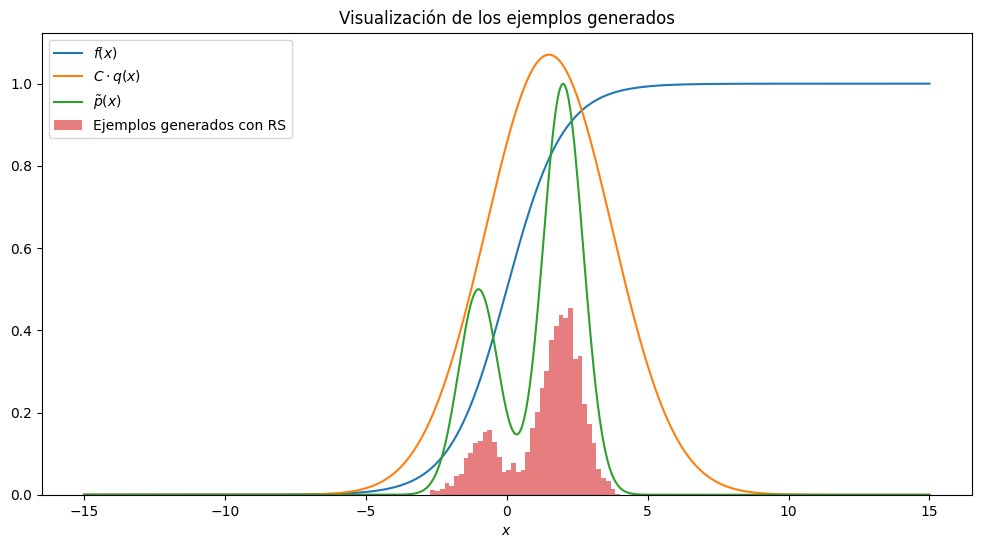

In [154]:
plt.figure(figsize=(12, 6))
plt.plot(x, y_f, label=r"$f(x)$")
plt.plot(x, y_C_q, label=r"$C \cdot q(x)$")
plt.plot(x, y_p_tilde, label=r"$\tilde{p}(x)$")
plt.hist(p_samples, bins=40, density=True, alpha=0.6, label="Ejemplos generados con RS")
plt.xlabel(r"$x$")
plt.title(r"Visualización de los ejemplos generados")
plt.legend()
plt.show()

In [155]:
E_f = np.mean(f(p_samples))
print(f"- La estimación del valor esperado de f(x) con x ~ p es: {E_f}")

- La estimación del valor esperado de f(x) con x ~ p es: 0.7363204114437909


9. ¿Cuál es el porcentaje de muestras rechazadas con cada $q$ probada?

In [156]:
def rejected_ratio(f, Cq_pdf, num_samples):
    num_accepted = 0
    num_rejected = 0
    while num_accepted < num_samples:
        x_i = np.random.normal(mu_val, var_val)
        u = np.random.uniform(0, max(Cq_pdf))
        if u < f(x_i):
            num_accepted += 1
        else:
            num_rejected += 1
    
    return (num_rejected / (num_rejected + num_samples))

ratios = []
for _ in range(20):
    ratio = rejected_ratio(f, y_C_q, N)
    ratios.append(ratio)
ratios = np.array(ratios)
print(f"- De media se rechaza un {(np.mean(ratios) * 100):.1f}% de las muestras generadas.")

- De media se rechaza un 34.2% de las muestras generadas.


- Podemos ver que el porcentaje de muestras rechazadas utilizando una distribución gaussiana como distribución propuesta disminuye sustancialmente respecto a la uniforme.